# Improving VWAP Roll Execution with a Predictive Ordered Logit

This notebook exposits and demonstrates the **rolling-window backtest** built in `src/backtest.py`
and `src/vwap.py`. The institutional roller's problem is to migrate a fixed quantity from the near
to the far contract over a roll period as cheaply as possible. The benchmark is **VWAP**; the goal is
to beat it using the predictive ordered-logit signal.

The pipeline, end to end:

1. **Data** - pull 2016-2025 spread bins and generate microstructure signals with the leakage-free
   *time-of-roll* volatility normalisation.
2. **Walk-forward windows** - 4y train / 1y validation / 3m test, sliding by one quarter.
3. **Volume curves** - the per-`qcode` VWAP execution schedule, profiled from prior rolls.
4. **Predictive ordered logit** - walk-forward out-of-sample classification of the next bin's move.
5. **Baseline VWAP** - passive-at-touch, cross the remainder; measure the spread captured.
6. **Ordered-logit overlay** - rest deeper when the model predicts a favourable move, cross
   immediately when it predicts an adverse one; compare head-to-head with the baseline.

All inference is strictly out-of-sample and leakage-controlled: signals are scaled only by prior
rolls, the model trains/tunes/tests on disjoint chronological slices, and volume curves use only
rolls that completed before the one being executed.

In [122]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import polars as pl
from plotnine import *
from plotnine.themes import theme_bw

from src.pipeline import build_datasets, generate_signals
from src.backtest import (
    generate_rolling_windows, windows_to_frame, split_tick_constrained,
    clean_delta_p_tc, run_rolling_backtest, predict_target_bins,
    compute_volume_curve, TICK_CONSTRAINED_BBG, TC_FEATURES,
)
from src.vwap import (
    run_vwap_backtest, run_improved_vwap_backtest, build_schedules, attach_tick_sizes,
)
from src.lob_simulation import simulate_windowed   # per-bin LOB sim (baseline & overlay)

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(30)
TARGET_QTY  = 10_000         # lots to roll per security
DIRECTION   = 'buy'          # buying calendar spreads
FILL_MODEL  = 'queue'         # price-range fills (needs HIGH/LOW)
WINDOW      = 3              # order survival window in bins (1 = naive single-bin)
WINDOW_GRID = [1, 2, 3, 4, 6, 12, 24, 36]  # 5 min .. 30 min, for the window-size sweep

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Data

`build_datasets` pulls the full history (2016-2025) of calendar-spread bins restricted to their roll
periods, with the near-leg `futures_price` attached. `generate_signals(..., normalization='time_of_roll')`
adds the microstructure signals (OBI / OFI / STV / NOI, tick-scaled `delta_p`) and normalises each flow
signal by a volatility profiled from **prior rolls only** - no train/test leakage, and no start-of-session
variance blow-up.

In [123]:
df_cs, df_combined = build_datasets(env_path='../.env', years=list(range(2016, 2026)))
df_signals = generate_signals(df_cs, normalization='time_of_roll')

print('df_cs     :', df_cs.shape)
print('df_signals:', df_signals.shape)
print('date range:', df_cs['date'].min(), '->', df_cs['date'].max())
print('qcodes    :', df_cs['qcode'].n_unique(), '| securities (rolls):', df_cs['security'].n_unique())
df_signals.select('security', 'date', 'bin_start_time', 'qcode', 'bbg_code',
                  'days_until', 'obi', 'ofi', 'stv', 'noi', 'delta_p').head()

Phys qcodes : ['TU', 'FV', 'GM', 'GH', 'IE', 'IL', 'BF', 'GX']
Cash qcodes : ['AZ', 'PI', 'HN', 'FX', 'SV', 'DF', 'ES', 'TT', 'NN', 'OX']
binned   : (13901208, 12)  (futures: 9,390,042  |  spreads: 4,511,166)
qmap     : (18, 5)
sec_meta : (1106, 3)


c:\Users\junwu.wang\Downloads\ip1\notebooks\..\src\pipeline.py:222: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided


df_cs       : (392969, 32)
df_fut      : (2030990, 29)
df_combined : (2423959, 32)
df_cs     : (392969, 32)
df_signals: (388951, 43)
date range: 2016-01-11 -> 2025-12-29
qcodes    : 18 | securities (rolls): 1040


security,date,bin_start_time,qcode,bbg_code,days_until,obi,ofi,stv,noi,delta_p
str,date,time,str,str,i32,f64,f64,f64,f64,f64
"""DU2016H/2016M Comdty""",2016-03-02,08:15:00,"""GH""","""DU""",4,-0.255481,null,null,null,0.0
"""DU2016H/2016M Comdty""",2016-03-02,08:20:00,"""GH""","""DU""",4,-0.228878,null,null,null,0.0
"""DU2016H/2016M Comdty""",2016-03-02,08:25:00,"""GH""","""DU""",4,-0.211953,null,null,null,0.0
"""DU2016H/2016M Comdty""",2016-03-02,08:30:00,"""GH""","""DU""",4,-0.124261,null,null,null,0.0
"""DU2016H/2016M Comdty""",2016-03-02,08:35:00,"""GH""","""DU""",4,-0.144185,null,null,null,0.0


## 2. Walk-forward windows

Each window trains on 4 years, tunes the decision threshold on the next 1 year, and tests on the
following 3 months - then everything slides forward by that 3-month test length, so the test
quarters tile the timeline without overlap. The first train window starts 2016-01-01.

In [124]:
windows = generate_rolling_windows(data_end=df_cs['date'].max())
print(f'{len(windows)} walk-forward windows')
windows_to_frame(windows)

19 walk-forward windows


index,train_start,train_end,val_start,val_end,test_start,test_end
i64,date,date,date,date,date,date
0,2016-01-01,2019-12-31,2020-01-01,2020-12-31,2021-01-01,2021-03-31
1,2016-04-01,2020-03-31,2020-04-01,2021-03-31,2021-04-01,2021-06-30
2,2016-07-01,2020-06-30,2020-07-01,2021-06-30,2021-07-01,2021-09-30
3,2016-10-01,2020-09-30,2020-10-01,2021-09-30,2021-10-01,2021-12-31
4,2017-01-01,2020-12-31,2021-01-01,2021-12-31,2022-01-01,2022-03-31
5,2017-04-01,2021-03-31,2021-04-01,2022-03-31,2022-04-01,2022-06-30
6,2017-07-01,2021-06-30,2021-07-01,2022-06-30,2022-07-01,2022-09-30
7,2017-10-01,2021-09-30,2021-10-01,2022-09-30,2022-10-01,2022-12-31
8,2018-01-01,2021-12-31,2022-01-01,2022-12-31,2023-01-01,2023-03-31


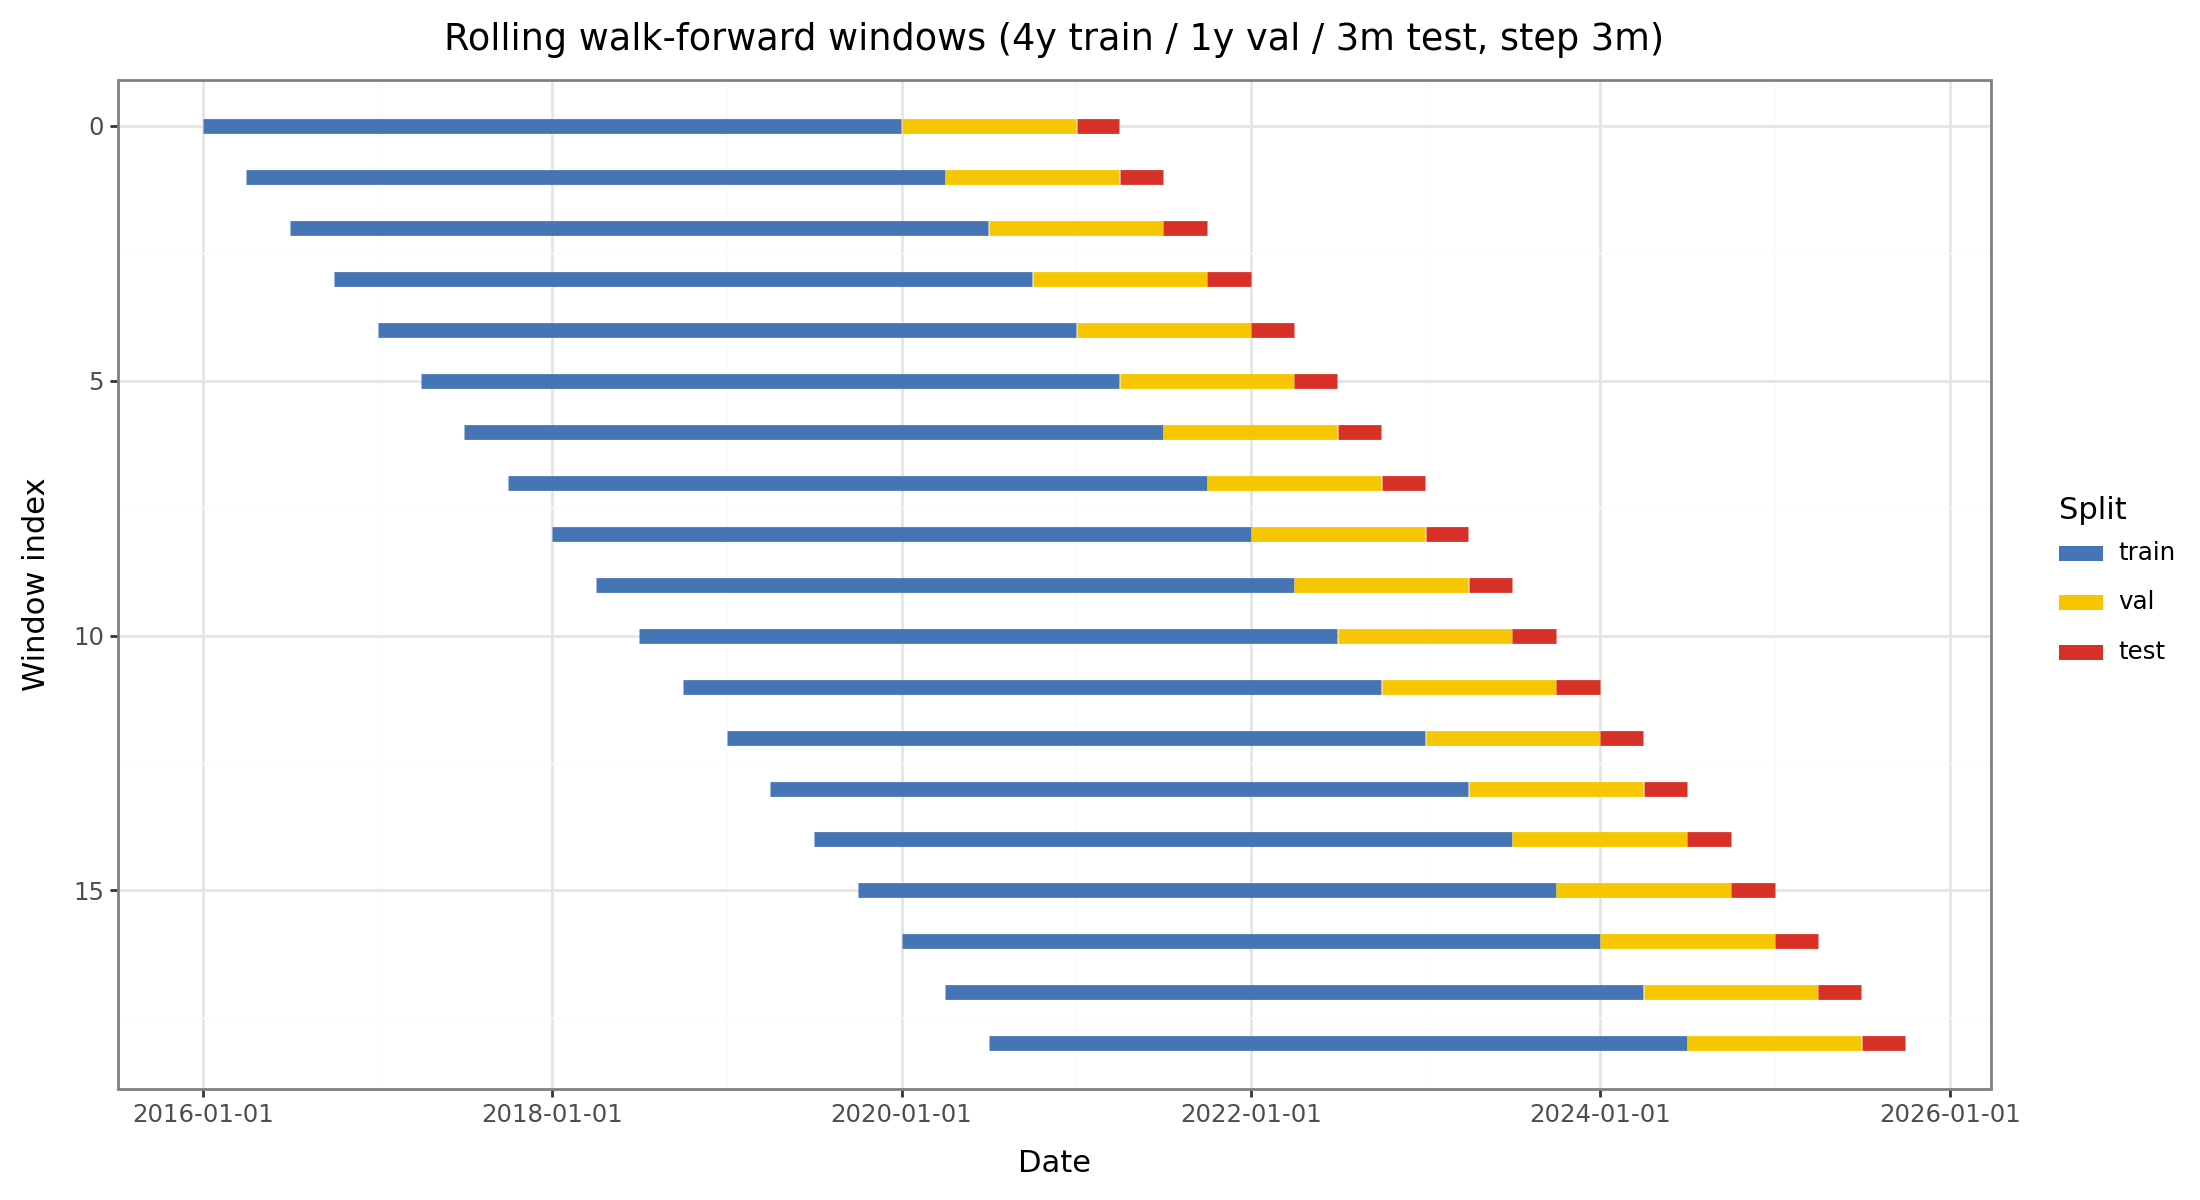

In [125]:
# Walk-forward layout: train / validation / test spans per window.
wf = windows_to_frame(windows).to_pandas()
seg = pd.DataFrame([
    {'window': int(r['index']), 'phase': ph, 'start': r[ph + '_start'], 'end': r[ph + '_end']}
    for _, r in wf.iterrows() for ph in ['train', 'val', 'test']
])
seg['start'] = pd.to_datetime(seg['start']); seg['end'] = pd.to_datetime(seg['end'])
seg['phase'] = pd.Categorical(seg['phase'], categories=['train', 'val', 'test'], ordered=True)

(
    ggplot(seg, aes(x='start', xend='end', y='window', yend='window', color='phase'))
    + geom_segment(size=3)
    + scale_color_manual(values={'train': '#4575b4', 'val': '#f6c700', 'test': '#d73027'})
    + scale_y_reverse()
    + labs(title='Rolling walk-forward windows (4y train / 1y val / 3m test, step 3m)',
           x='Date', y='Window index', color='Split')
    + theme_bw(base_size=11) + theme(figure_size=(11, 6))
)

## 3. Volume curves - the VWAP schedule

For each `qcode`, `compute_volume_curve` averages, across its rolls, the fraction of total roll volume
traded in each (days-to-target, time-of-day) bucket. This is the schedule a VWAP slicer follows: work
more where the market historically trades more. In the backtest the curve is leakage-safe (built only
from rolls that completed before the one being executed); here we show the full-sample curve for
exposition.

heatmap qcode: SV


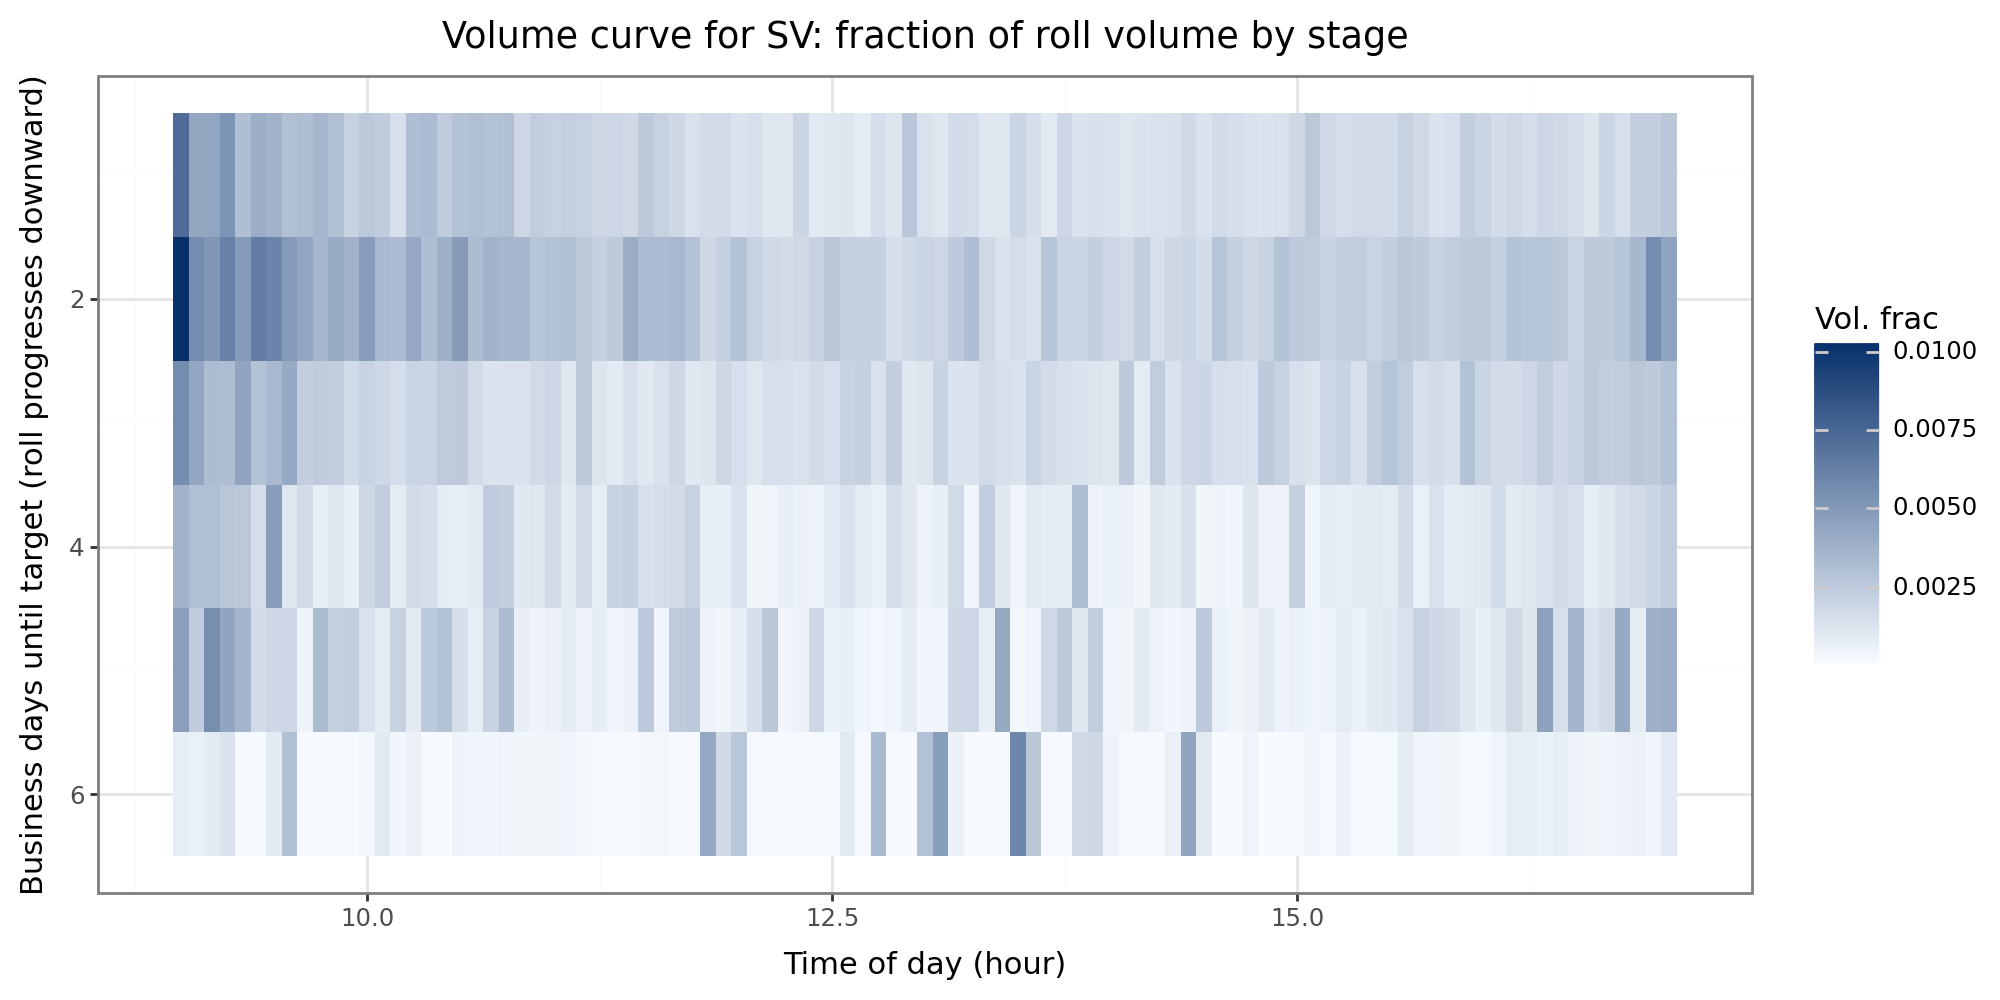

In [126]:
vol_curve = compute_volume_curve(df_cs)

# Focus on the most-traded tick-constrained qcode for the heatmap.
top_q = (
    df_cs.filter(pl.col('bbg_code').is_in(TICK_CONSTRAINED_BBG))
    .group_by('qcode').len().sort('len', descending=True)['qcode'][0]
)
q_curve = (
    vol_curve.filter(pl.col('qcode') == top_q)
    .with_columns(hour=pl.col('bin_start_time').dt.hour() + pl.col('bin_start_time').dt.minute() / 60)
    .to_pandas()
)
print('heatmap qcode:', top_q)

(
    ggplot(q_curve, aes(x='hour', y='days_until', fill='volume_fraction'))
    + geom_tile()
    + scale_fill_gradient(low='#f7fbff', high='#08306b', name='Vol. frac')
    + scale_y_reverse()
    + labs(title=f'Volume curve for {top_q}: fraction of roll volume by stage',
           x='Time of day (hour)', y='Business days until target (roll progresses downward)')
    + theme_bw(base_size=11) + theme(figure_size=(10, 5))
)

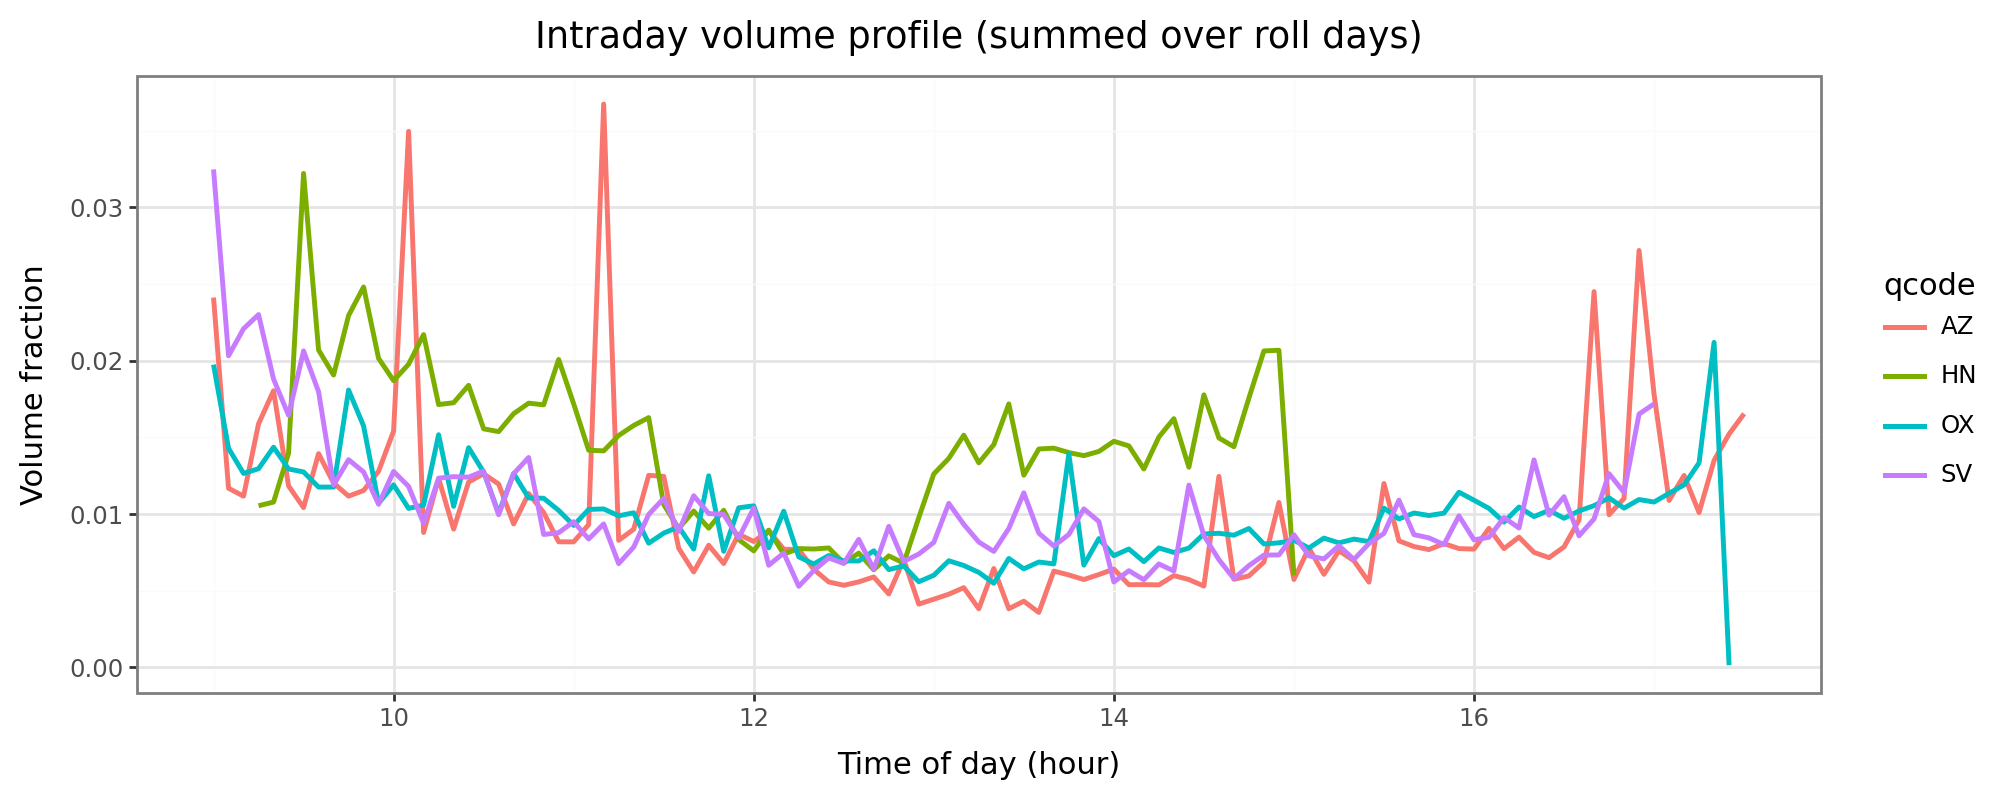

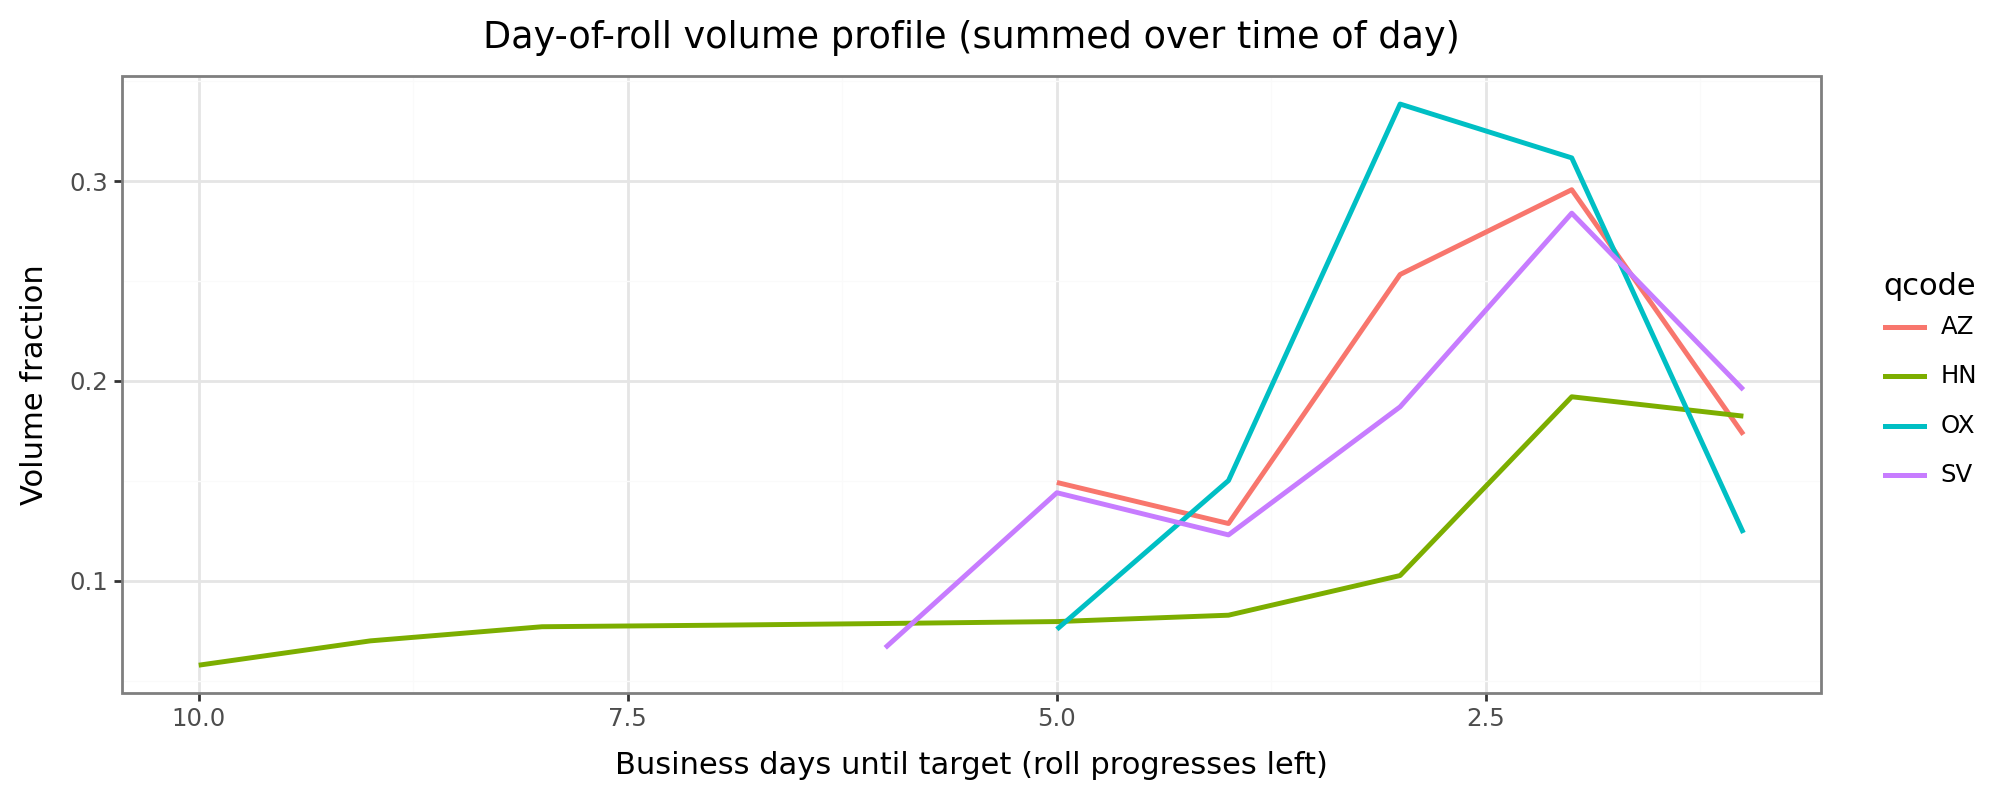

In [127]:
# Marginal curves: intraday shape and day-of-roll shape, for the busiest qcodes.
busy = (df_cs.group_by('qcode').len().sort('len', descending=True)['qcode'].head(4).to_list())

intraday = (
    vol_curve.filter(pl.col('qcode').is_in(busy))
    .with_columns(hour=pl.col('bin_start_time').dt.hour() + pl.col('bin_start_time').dt.minute() / 60)
    .group_by('qcode', 'hour').agg(frac=pl.col('volume_fraction').sum())
    .to_pandas()
)
p_intraday = (
    ggplot(intraday, aes('hour', 'frac', color='qcode'))
    + geom_line(size=1)
    + labs(title='Intraday volume profile (summed over roll days)', x='Time of day (hour)',
           y='Volume fraction', color='qcode')
    + theme_bw(base_size=11) + theme(figure_size=(10, 4))
)

by_day = (
    vol_curve.filter(pl.col('qcode').is_in(busy))
    .group_by('qcode', 'days_until').agg(frac=pl.col('volume_fraction').sum())
    .to_pandas()
)
p_byday = (
    ggplot(by_day, aes('days_until', 'frac', color='qcode'))
    + geom_line(size=1) + scale_x_reverse()
    + labs(title='Day-of-roll volume profile (summed over time of day)',
           x='Business days until target (roll progresses left)', y='Volume fraction', color='qcode')
    + theme_bw(base_size=11) + theme(figure_size=(10, 4))
)
display(p_intraday); display(p_byday)

## 4. Predictive ordered logit, walk-forward

We restrict to the **tick-constrained** curve groups (which trade on a near-discrete grid), clean
`delta_p` to the ordered set {-2, 0, +2}, and run the class-weighted ordered logit walk-forward: fit on
train, tune the **-2 and +2 thresholds independently** on validation (each maximising its tail's
F-beta, β=0.5 → precision-weighted), evaluate on the held-out test quarter. Each window's
out-of-sample macro-F-beta is plotted over time.

In [128]:
_, df_signals_tc = split_tick_constrained(df_signals)
df_clean = clean_delta_p_tc(df_signals_tc)
print('tick-constrained cleaned rows:', df_clean.shape,
      '| class balance:', df_clean['delta_p'].value_counts(sort=True).to_dict())

results = run_rolling_backtest(df_clean, windows, verbose=False)
results.filter(pl.col('status') == 'ok').select(
    'label', 'thr_down', 'thr_up', 'val_fbeta_down', 'val_fbeta_up',
    'test_macro_fbeta', 'test_accuracy', 'n_train', 'n_test'
)

tick-constrained cleaned rows: (218073, 44) | class balance: {'delta_p': shape: (3,)
Series: 'delta_p' [i32]
[
	0
	2
	-2
], 'count': shape: (3,)
Series: 'count' [u32]
[
	194397
	12016
	11660
]}


label,thr_down,thr_up,val_fbeta_down,val_fbeta_up,test_macro_fbeta,test_accuracy,n_train,n_test
str,f64,f64,f64,f64,f64,f64,i64,i64
"""W00 test 2021-01..2021-03""",0.605,0.65,0.208481,0.2573,0.412045,0.766769,78677,5218
"""W01 test 2021-04..2021-06""",0.78,0.81,0.199197,0.222678,0.417766,0.918216,83521,5270
"""W02 test 2021-07..2021-09""",0.775,0.82,0.205712,0.216193,0.40582,0.881885,83813,5410
"""W03 test 2021-10..2021-12""",0.78,0.685,0.19514,0.189816,0.495872,0.84252,84061,5334
"""W04 test 2022-01..2022-03""",0.825,0.825,0.220909,0.232952,0.40857,0.831742,84847,5343
"""W05 test 2022-04..2022-06""",0.775,0.725,0.234048,0.253541,0.464527,0.7329,84020,5687
"""W06 test 2022-07..2022-09""",0.765,0.705,0.258329,0.292676,0.448262,0.697477,83943,5431
"""W07 test 2022-10..2022-12""",0.68,0.69,0.304586,0.328135,0.521028,0.749153,83656,5314
"""W08 test 2023-01..2023-03""",0.675,0.685,0.326036,0.358053,0.539512,0.772974,83848,5343


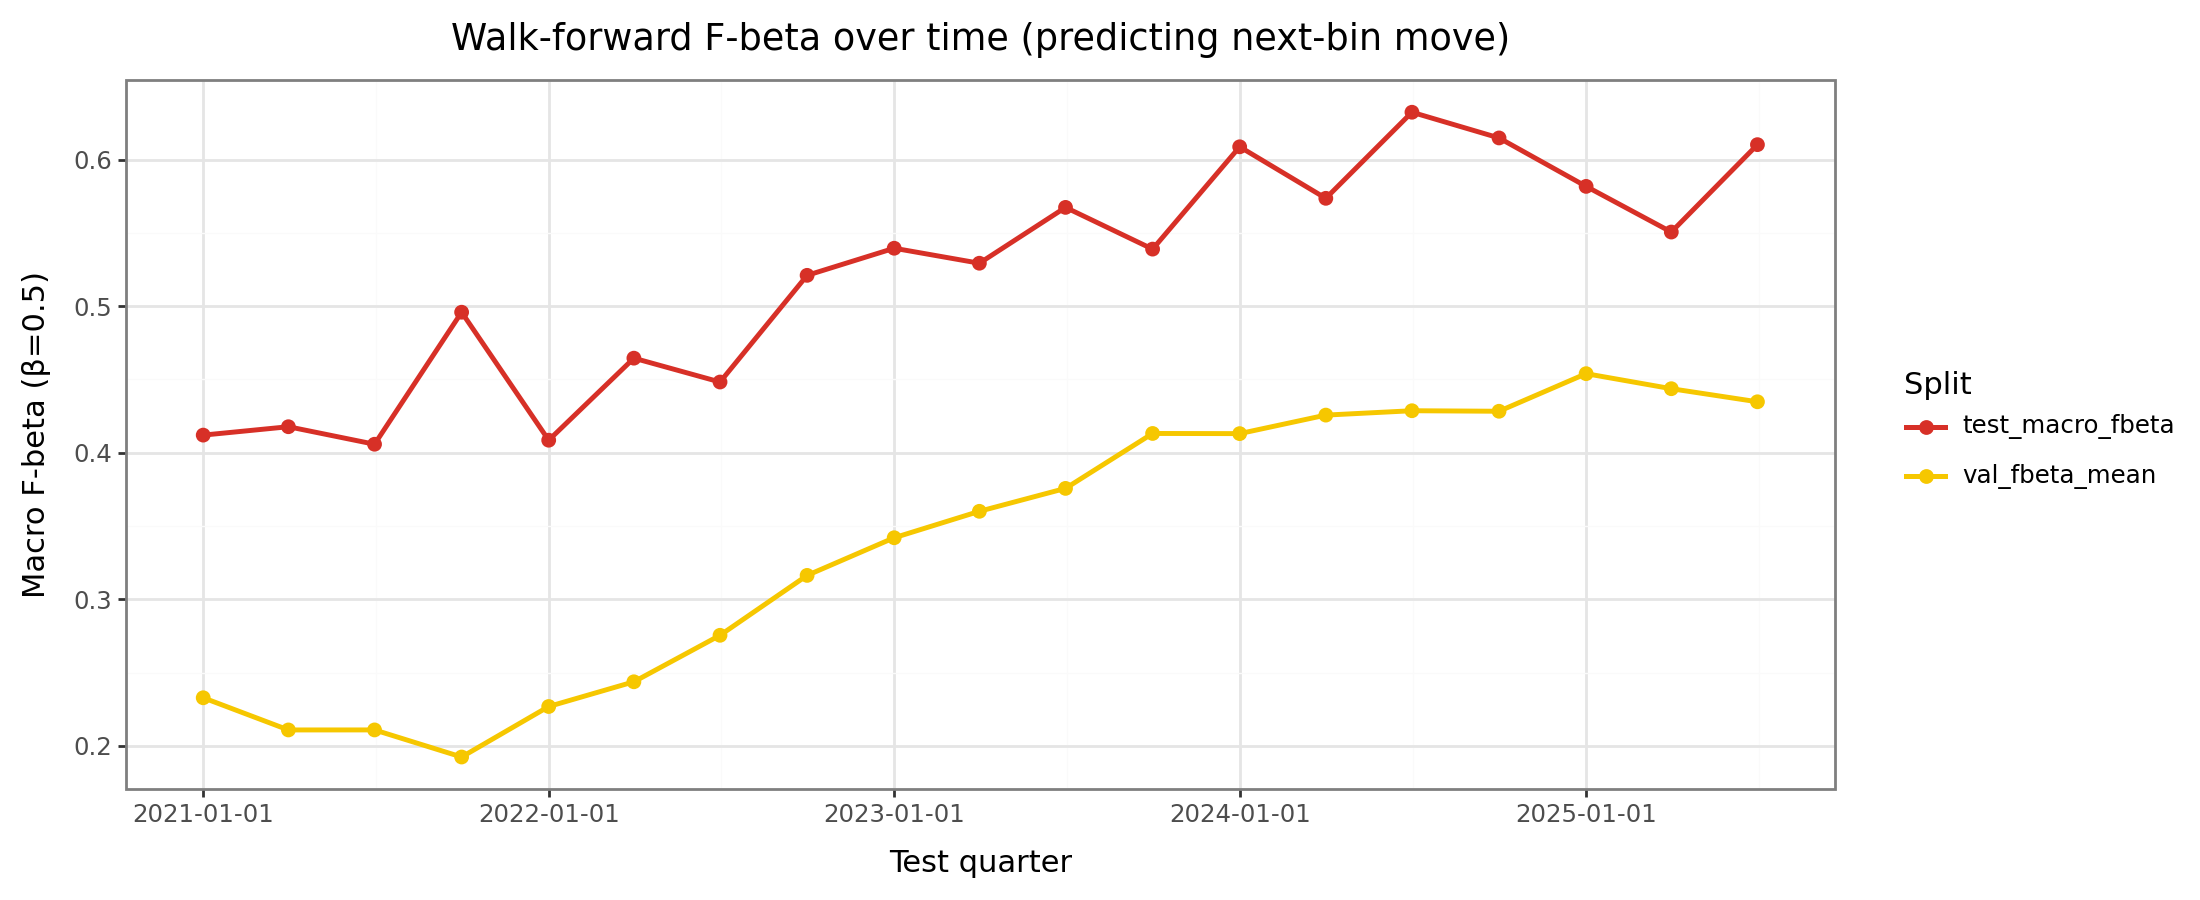

In [129]:
ok = results.filter(pl.col('status') == 'ok').with_columns(
    val_fbeta_mean=(pl.col('val_fbeta_down') + pl.col('val_fbeta_up')) / 2
)
fb = ok.select('test_start', 'val_fbeta_mean', 'test_macro_fbeta').to_pandas()
fb['test_start'] = pd.to_datetime(fb['test_start'])
fbm = fb.melt(id_vars='test_start', var_name='split', value_name='fbeta')

(
    ggplot(fbm, aes('test_start', 'fbeta', color='split'))
    + geom_line(size=1) + geom_point(size=2)
    + scale_color_manual(values={'val_fbeta_mean': '#f6c700', 'test_macro_fbeta': '#d73027'})
    + labs(title='Walk-forward F-beta over time (predicting next-bin move)',
           x='Test quarter', y='Macro F-beta (β=0.5)', color='Split')
    + theme_bw(base_size=11) + theme(figure_size=(11, 4.5))
)

## 5. Baseline VWAP execution

The baseline rests a passive limit at the touch (best bid when buying) for each bin's scheduled
quantity; whatever fills passively **saves the spread**. With a survival **window** of `W` bins an
order rests for `W` bins before its unfilled remainder crosses at the end of the window — `W=1` is the
naive single-bin scheme, while larger `W` lets the order sit across several bins and fill against more
opposing flow (essential in tick-constrained books where one bin rarely clears the queue). Orders whose
window reaches the session close are cleaned up at the last bin (no overnight risk). Costs are signed so
positive = unfavourable, reported in two frameworks: **ticks per lot** (the default — e.g. always
crossing a 1-tick spread costs half a tick over mid) and basis points of the future price.

rolls executed       : 504
passive fill rate    : 0.179
cost vs market VWAP  : +1.158 ticks/lot  (+0.52 bp)
cost vs mid (ideal)  : +0.951 ticks/lot  (+0.45 bp)
avg half-spread      : 1.130 ticks       (0.52 bp)


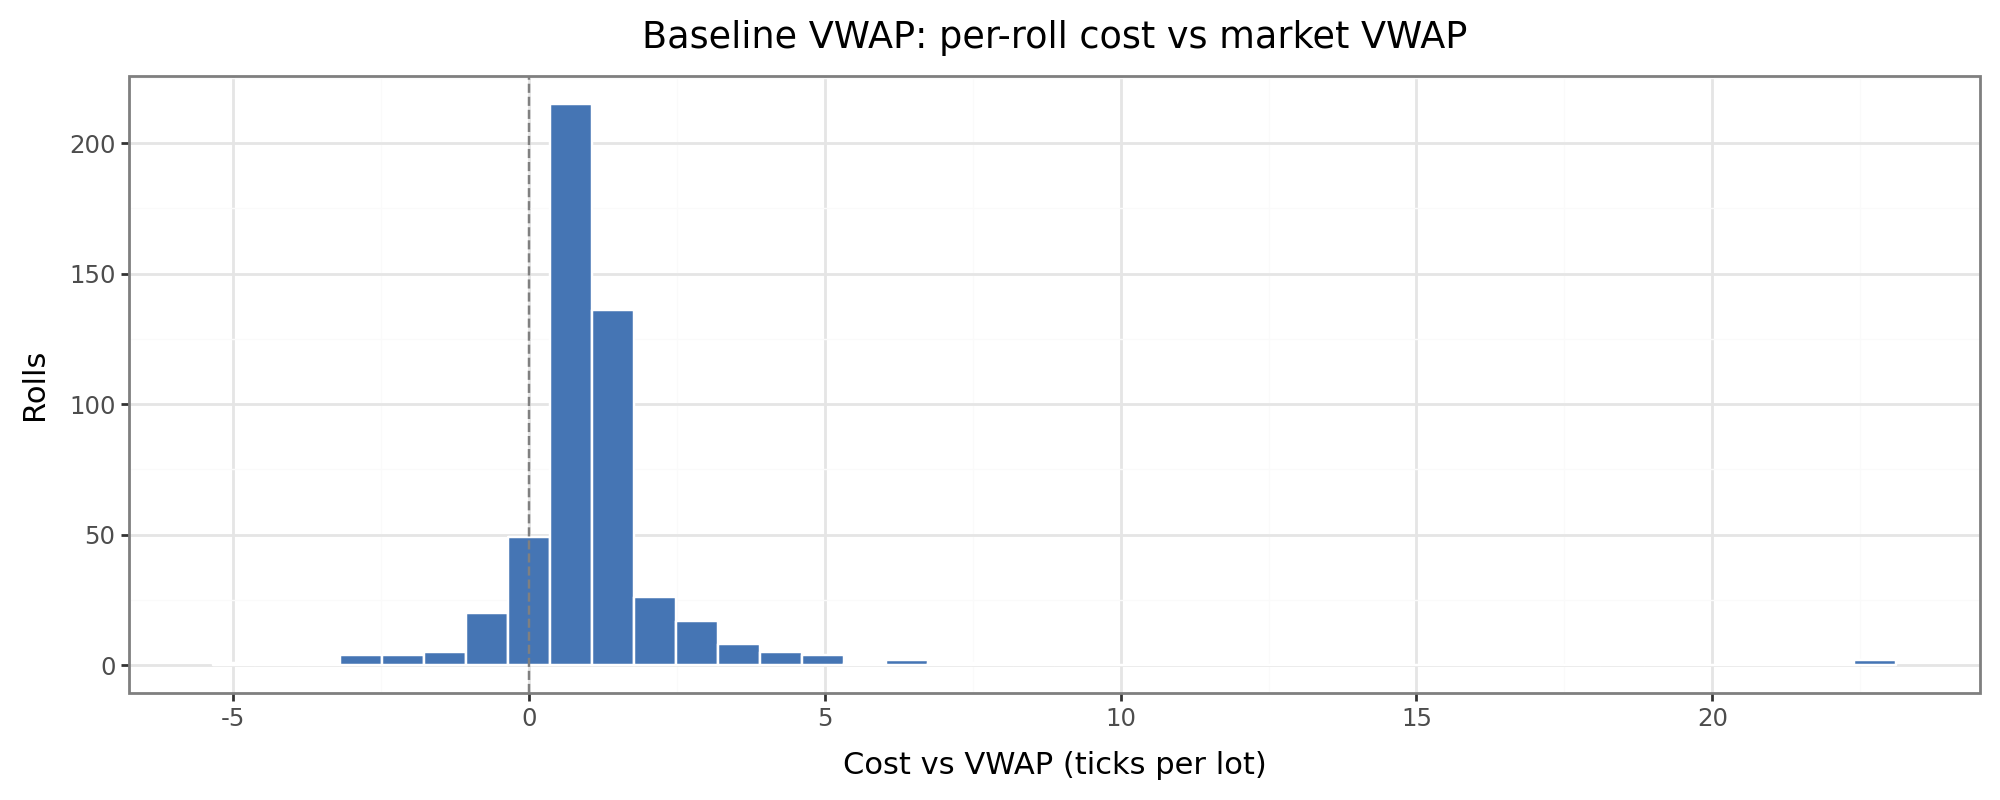

In [130]:
df_tc = df_cs.filter(pl.col('bbg_code').is_in(TICK_CONSTRAINED_BBG))
per_base, summ_base = run_vwap_backtest(
    df_tc, target_qty=TARGET_QTY, direction=DIRECTION, fill_model=FILL_MODEL,
    window=WINDOW, df_signals=df_signals,
)
print(f'rolls executed       : {per_base.height}')
print(f'passive fill rate    : {summ_base["passive_rate"]:.3f}')
print(f'cost vs market VWAP  : {summ_base["cost_vs_vwap_ticks"]:+.3f} ticks/lot  ({summ_base["cost_vs_vwap_bp"]:+.2f} bp)')
print(f'cost vs mid (ideal)  : {summ_base["cost_vs_mid_ticks"]:+.3f} ticks/lot  ({summ_base["cost_vs_mid_bp"]:+.2f} bp)')
print(f'avg half-spread      : {summ_base["half_spread_ticks"]:.3f} ticks       ({summ_base["half_spread_bp"]:.2f} bp)')

pb = per_base.to_pandas()
(
    ggplot(pb, aes('cost_vs_vwap_ticks'))
    + geom_histogram(bins=40, fill='#4575b4', color='white')
    + geom_vline(xintercept=0, linetype='dashed', color='grey')
    + labs(title='Baseline VWAP: per-roll cost vs market VWAP',
           x='Cost vs VWAP (ticks per lot)', y='Rolls')
    + theme_bw(base_size=11) + theme(figure_size=(10, 4))
)

## 6. Ordered-logit VWAP overlay

The overlay uses the model's prediction for each target bin (known at its start). When buying:

- predicted **down** (favourable) -> rest the limit **2 ticks below** the bid to capture a better price;
- predicted **up** (adverse) -> **cross immediately** at the bin's start, beating the higher ask later;
- predicted **flat** -> behave like the baseline.

`predict_target_bins` produces the out-of-sample, session-shifted predictions; `run_improved_vwap_backtest`
schedules once and runs both strategies on the **same** rolls for a like-for-like comparison.

Aggregate improvement is computed **per lot**: each roll is weighted by the lots it executes (`total_qty`,
which follows the volume curve and equals `TARGET_QTY` by conservation), exactly as
`summary['improvement_vs_baseline']` pools lots. A plain mean of per-roll ratios, or a market-*volume*
weighting (a different quantity), is not per-lot and can disagree in sign with the portfolio number.

In [131]:
preds = predict_target_bins(df_clean, windows, verbose=False)
print('predicted target bins:', preds.shape,
      '| class mix:', preds['pred'].value_counts(sort=True).to_dict())

summary, per_sec = run_improved_vwap_backtest(
    df_cs, preds, df_signals,
    target_qty=TARGET_QTY, direction=DIRECTION, fill_model=FILL_MODEL, window=WINDOW, framework='ticks',
)
# `per_sec.total_qty` = lots executed per roll (follows the volume curve; = TARGET_QTY by
# conservation). It is the correct PER-LOT weight for aggregating per-roll improvement -- the same
# lots that summary['improvement_vs_baseline'] pools over. Weighting by *market* volume instead is
# a different quantity that over-weights high-volume rolls and can flip the aggregate's sign.

# Headline framework is ticks per lot; bp columns are present too.
summary.select('strategy', 'framework', 'passive_rate', 'exec_avg_price',
               'cost_vs_vwap_ticks', 'cost_vs_mid_ticks', 'cost_vs_vwap_bp', 'improvement_vs_baseline')

predicted target bins: (98225, 8) | class mix: {'pred': shape: (3,)
Series: 'pred' [i64]
[
	0
	2
	-2
], 'count': shape: (3,)
Series: 'count' [u32]
[
	87440
	6159
	4626
]}


strategy,framework,passive_rate,exec_avg_price,cost_vs_vwap_ticks,cost_vs_mid_ticks,cost_vs_vwap_bp,improvement_vs_baseline
str,str,f64,f64,f64,f64,f64,f64
"""baseline_vwap""","""ticks""",0.189491,1.751968,1.158455,0.836887,0.545163,0.010323
"""ordered_logit_vwap""","""ticks""",0.163697,1.751219,1.148132,0.826564,0.536961,0.010323


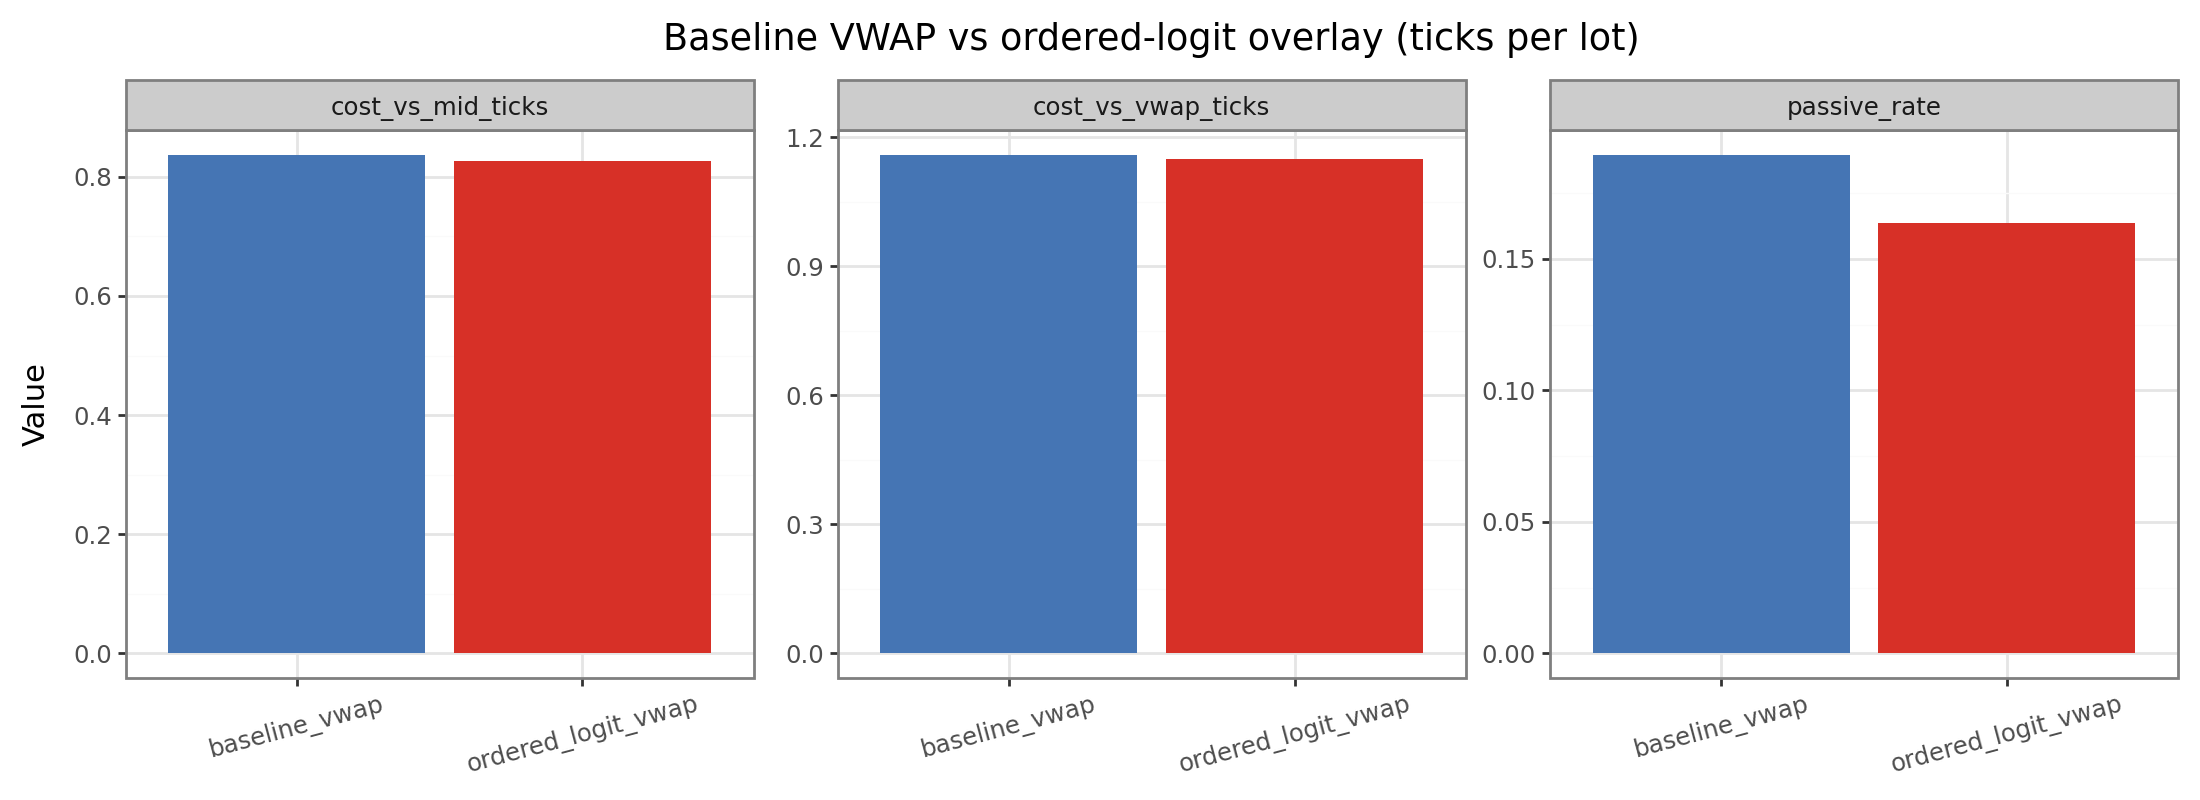

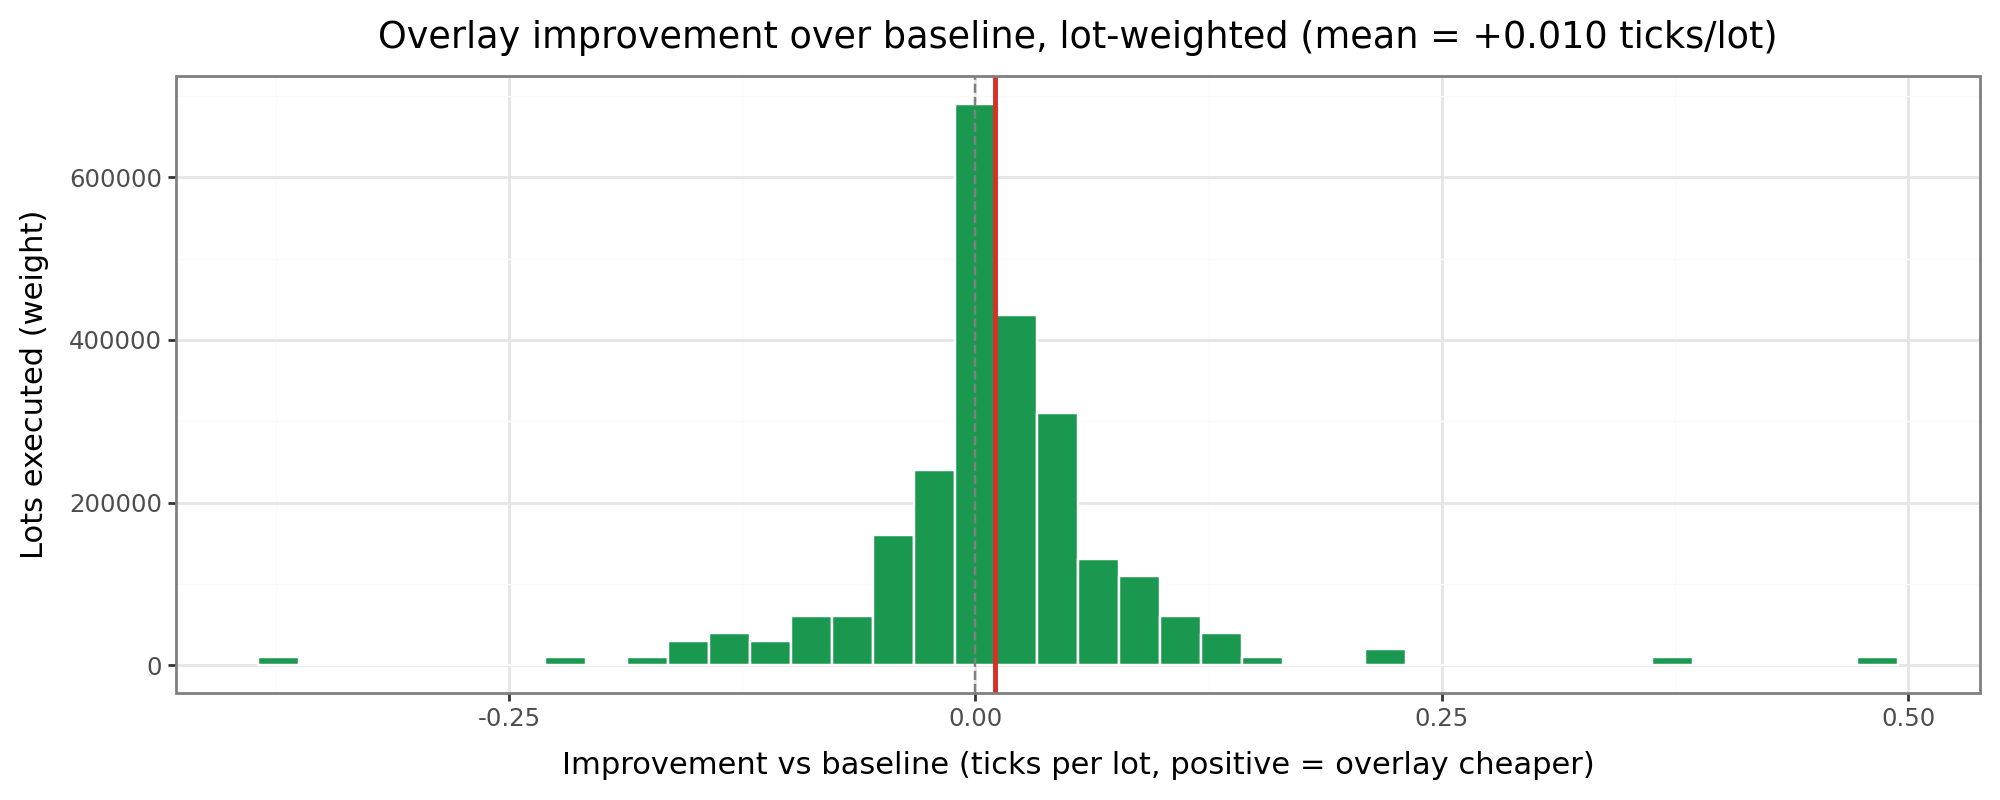

In [132]:
# Head-to-head: passive rate and cost vs VWAP / mid (ticks per lot), baseline vs overlay.
sm = summary.select('strategy', 'passive_rate', 'cost_vs_vwap_ticks', 'cost_vs_mid_ticks').to_pandas()
sm_long = sm.melt(id_vars='strategy', var_name='metric', value_name='value')
sm_long['strategy'] = pd.Categorical(sm_long['strategy'], ['baseline_vwap', 'ordered_logit_vwap'])

p_cmp = (
    ggplot(sm_long, aes('strategy', 'value', fill='strategy'))
    + geom_col(show_legend=False)
    + facet_wrap('~metric', scales='free_y')
    + scale_fill_manual(values={'baseline_vwap': '#4575b4', 'ordered_logit_vwap': '#d73027'})
    + labs(title='Baseline VWAP vs ordered-logit overlay (ticks per lot)', x='', y='Value')
    + theme_bw(base_size=11) + theme(figure_size=(11, 4), axis_text_x=element_text(rotation=15))
)
display(p_cmp)

# Per-roll improvement (positive = overlay cheaper), ticks/lot. PER-LOT basis: the histogram and the
# red mean line are weighted by lots executed per roll ('total_qty'), so the mean agrees in sign with
# summary['improvement_vs_baseline'] (NOT a market-volume weighting, which flipped the sign).
ps = per_sec.drop_nulls('improvement_vs_vwap').to_pandas()
lot_mean = np.average(ps['improvement_vs_vwap'], weights=ps['total_qty'])
p_impr = (
    ggplot(ps, aes('improvement_vs_vwap', weight='total_qty'))
    + geom_histogram(bins=40, fill='#1a9850', color='white')
    + geom_vline(xintercept=0, linetype='dashed', color='grey')
    + geom_vline(xintercept=lot_mean, color='#d73027', size=1)
    + labs(title=f'Overlay improvement over baseline, lot-weighted (mean = {lot_mean:+.3f} ticks/lot)',
           x='Improvement vs baseline (ticks per lot, positive = overlay cheaper)',
           y='Lots executed (weight)')
    + theme_bw(base_size=11) + theme(figure_size=(10, 4))
)
display(p_impr)

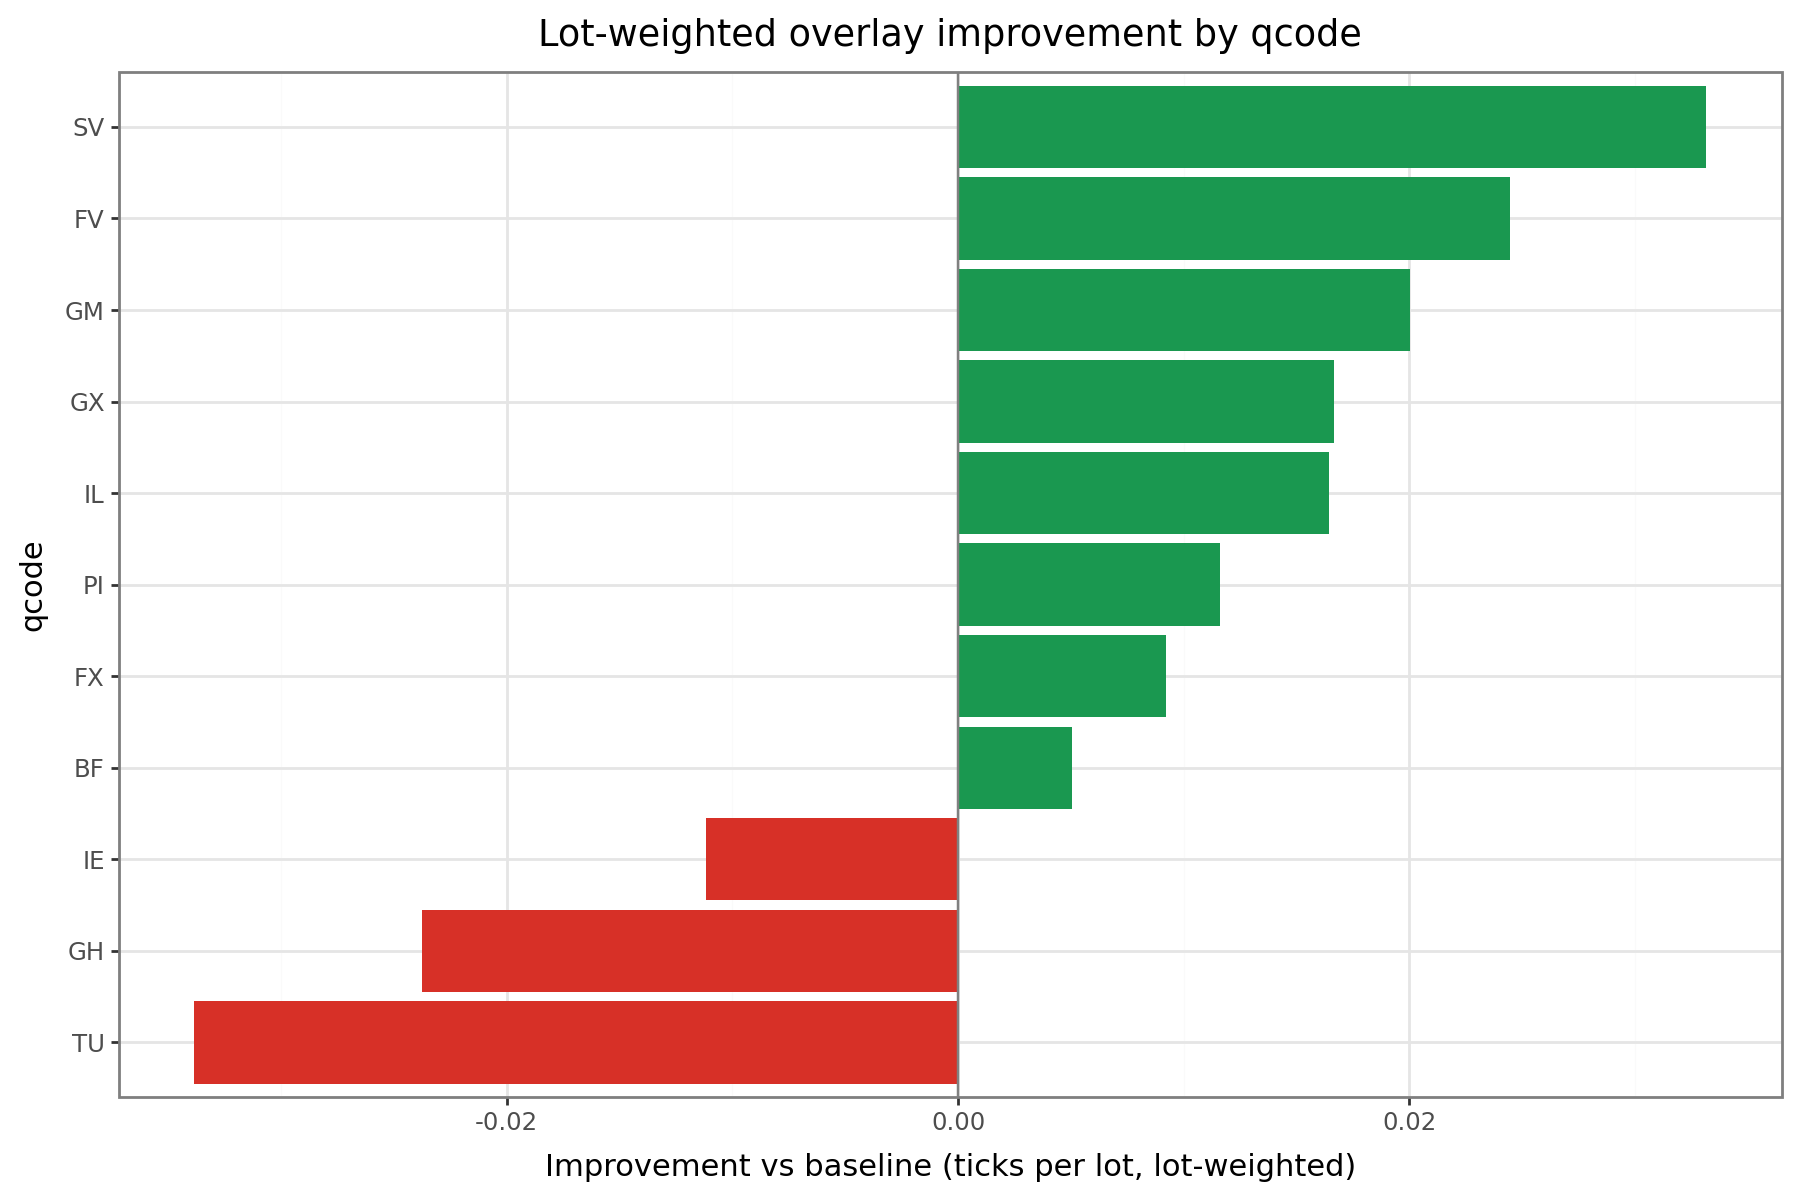

In [133]:
# Where does the overlay help or hurt? Per-qcode improvement, weighted by lots executed (per-lot):
# within each qcode, rolls are weighted by their executed lots ('total_qty'), matching summary.
by_q = (
    per_sec.drop_nulls('improvement_vs_vwap')
    .group_by('qcode').agg(
        lot_improvement_ticks=(pl.col('improvement_vs_vwap') * pl.col('total_qty')).sum()
                              / pl.col('total_qty').sum(),
        rolls=pl.len(),
        lots=pl.col('total_qty').sum(),
    ).sort('lot_improvement_ticks')
    .to_pandas()
)
by_q['qcode'] = pd.Categorical(by_q['qcode'], categories=by_q['qcode'].tolist(), ordered=True)
(
    ggplot(by_q, aes('qcode', 'lot_improvement_ticks', fill='lot_improvement_ticks > 0'))
    + geom_col(show_legend=False)
    + geom_hline(yintercept=0, color='grey')
    + scale_fill_manual(values={True: '#1a9850', False: '#d73027'})
    + coord_flip()
    + labs(title='Lot-weighted overlay improvement by qcode', x='qcode',
           y='Improvement vs baseline (ticks per lot, lot-weighted)')
    + theme_bw(base_size=11) + theme(figure_size=(9, 6))
)

## 6b. Sweeping the survival window

The survival window trades off **fill rate against adverse selection**: a longer window lets passive
orders fill more often (saving the spread), but an order that sits longer is more likely to be run over
by an adverse move. We sweep `WINDOW_GRID` and track the passive-fill rate and cost vs market VWAP for
the baseline and the overlay. Predictions are window-independent, so they are reused across the sweep.

In [134]:
sweep_rows = []
for W in WINDOW_GRID:
    s_w, _ = run_improved_vwap_backtest(
        df_cs, preds, df_signals,
        target_qty=TARGET_QTY, direction=DIRECTION, fill_model=FILL_MODEL, window=W, framework='ticks',
    )
    for r in s_w.iter_rows(named=True):
        sweep_rows.append(dict(window=W, strategy=r['strategy'], passive_rate=r['passive_rate'],
                               cost_vs_vwap_ticks=r['cost_vs_vwap_ticks'],
                               cost_vs_mid_ticks=r['cost_vs_mid_ticks']))
sweep = pl.DataFrame(sweep_rows)
sweep

window,strategy,passive_rate,cost_vs_vwap_ticks,cost_vs_mid_ticks
i64,str,f64,f64,f64
1,"""baseline_vwap""",0.094066,1.258911,0.937343
1,"""ordered_logit_vwap""",0.082094,1.257562,0.935994
2,"""baseline_vwap""",0.148405,1.203051,0.881483
2,"""ordered_logit_vwap""",0.129294,1.19325,0.871682
3,"""baseline_vwap""",0.189491,1.158455,0.836887
3,"""ordered_logit_vwap""",0.163697,1.148132,0.826564
4,"""baseline_vwap""",0.223262,1.118559,0.796991
4,"""ordered_logit_vwap""",0.191902,1.109278,0.78771
6,"""baseline_vwap""",0.276328,1.057566,0.735998


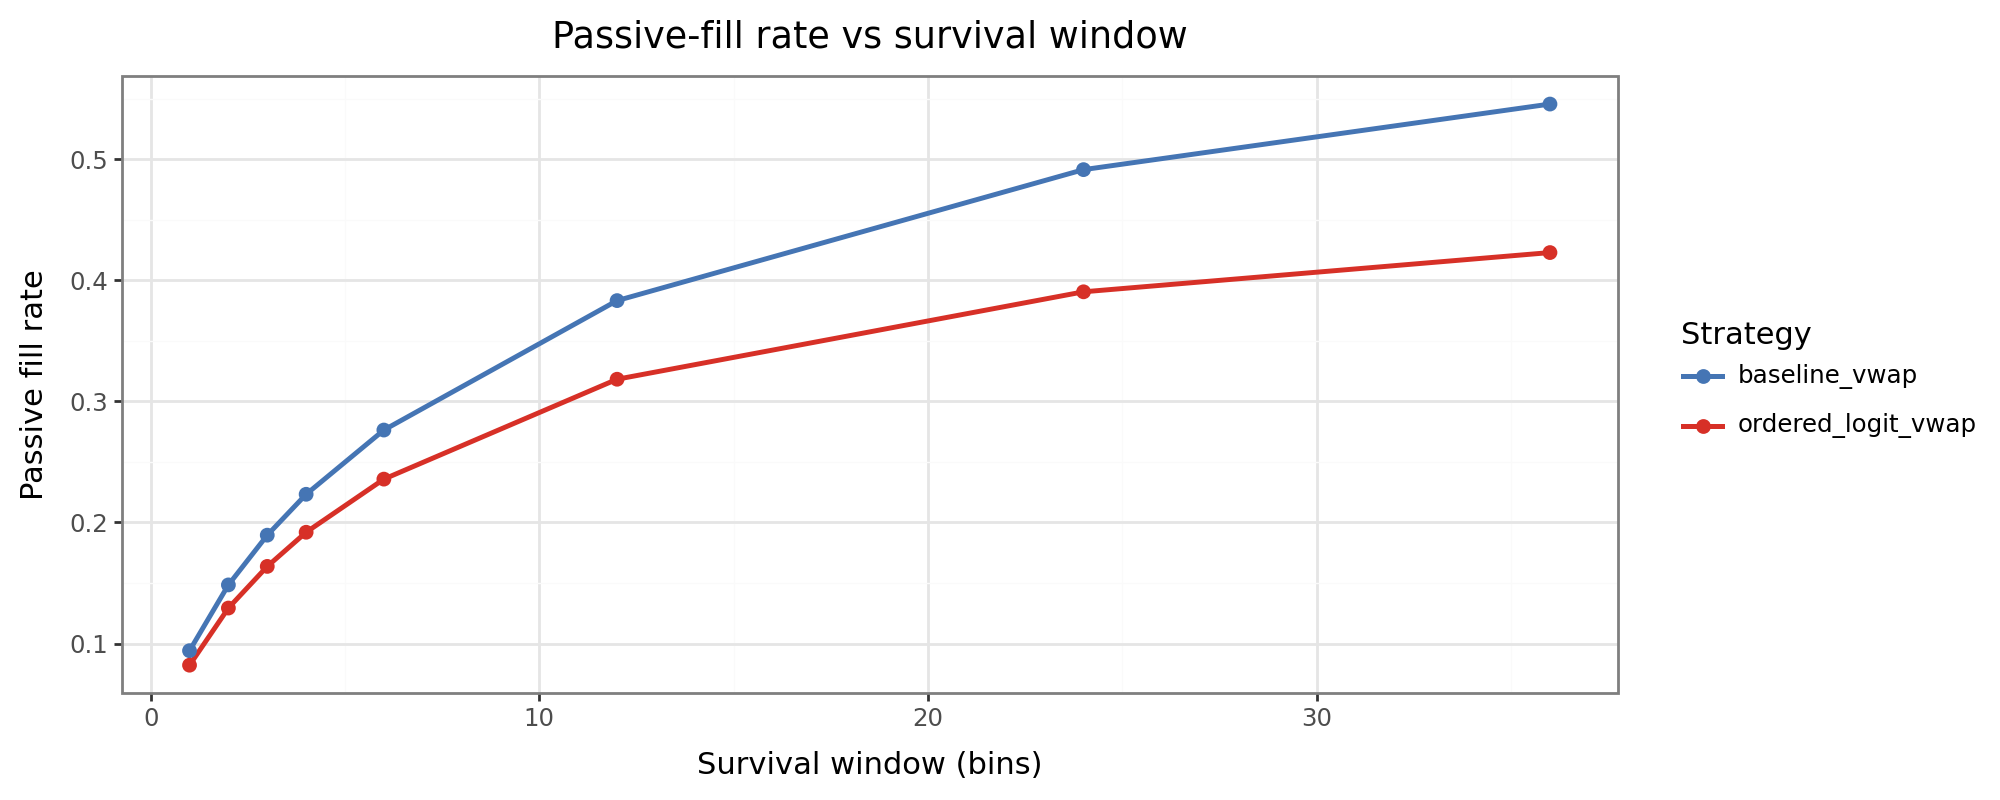

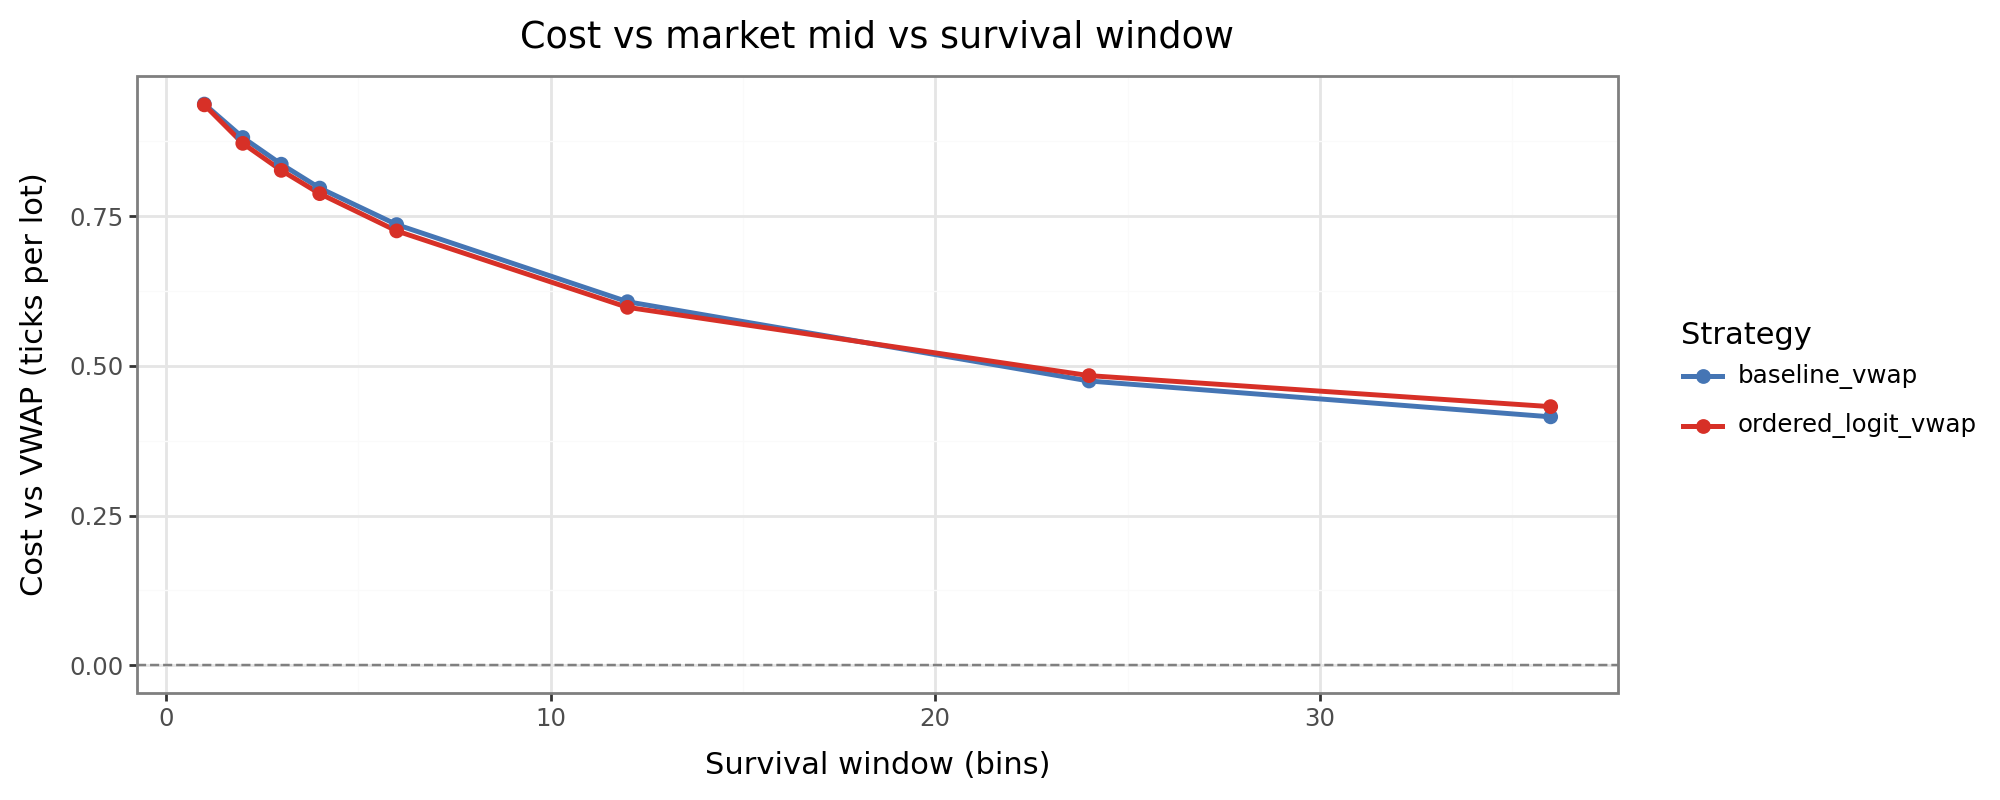

In [135]:
sw = sweep.to_pandas()

p_pr = (
    ggplot(sw, aes('window', 'passive_rate', color='strategy'))
    + geom_line(size=1) + geom_point(size=2)
    + scale_color_manual(values={'baseline_vwap': '#4575b4', 'ordered_logit_vwap': '#d73027'})
    + labs(title='Passive-fill rate vs survival window', x='Survival window (bins)',
           y='Passive fill rate', color='Strategy')
    + theme_bw(base_size=11) + theme(figure_size=(10, 4))
)
p_cost = (
    ggplot(sw, aes('window', 'cost_vs_mid_ticks', color='strategy'))
    + geom_line(size=1) + geom_point(size=2)
    + geom_hline(yintercept=0, linetype='dashed', color='grey')
    + scale_color_manual(values={'baseline_vwap': '#4575b4', 'ordered_logit_vwap': '#d73027'})
    + labs(title='Cost vs market mid vs survival window', x='Survival window (bins)',
           y='Cost vs VWAP (ticks per lot)', color='Strategy')
    + theme_bw(base_size=11) + theme(figure_size=(10, 4))
)
display(p_pr); display(p_cost)

## 7. A single roll, illustrated

To make the schedule concrete, take one out-of-sample roll and show how the target quantity is spread
across the roll by the historical volume curve (aggregated to business-days-until-target).

illustrated roll: TU2022Z/2023H Comdty


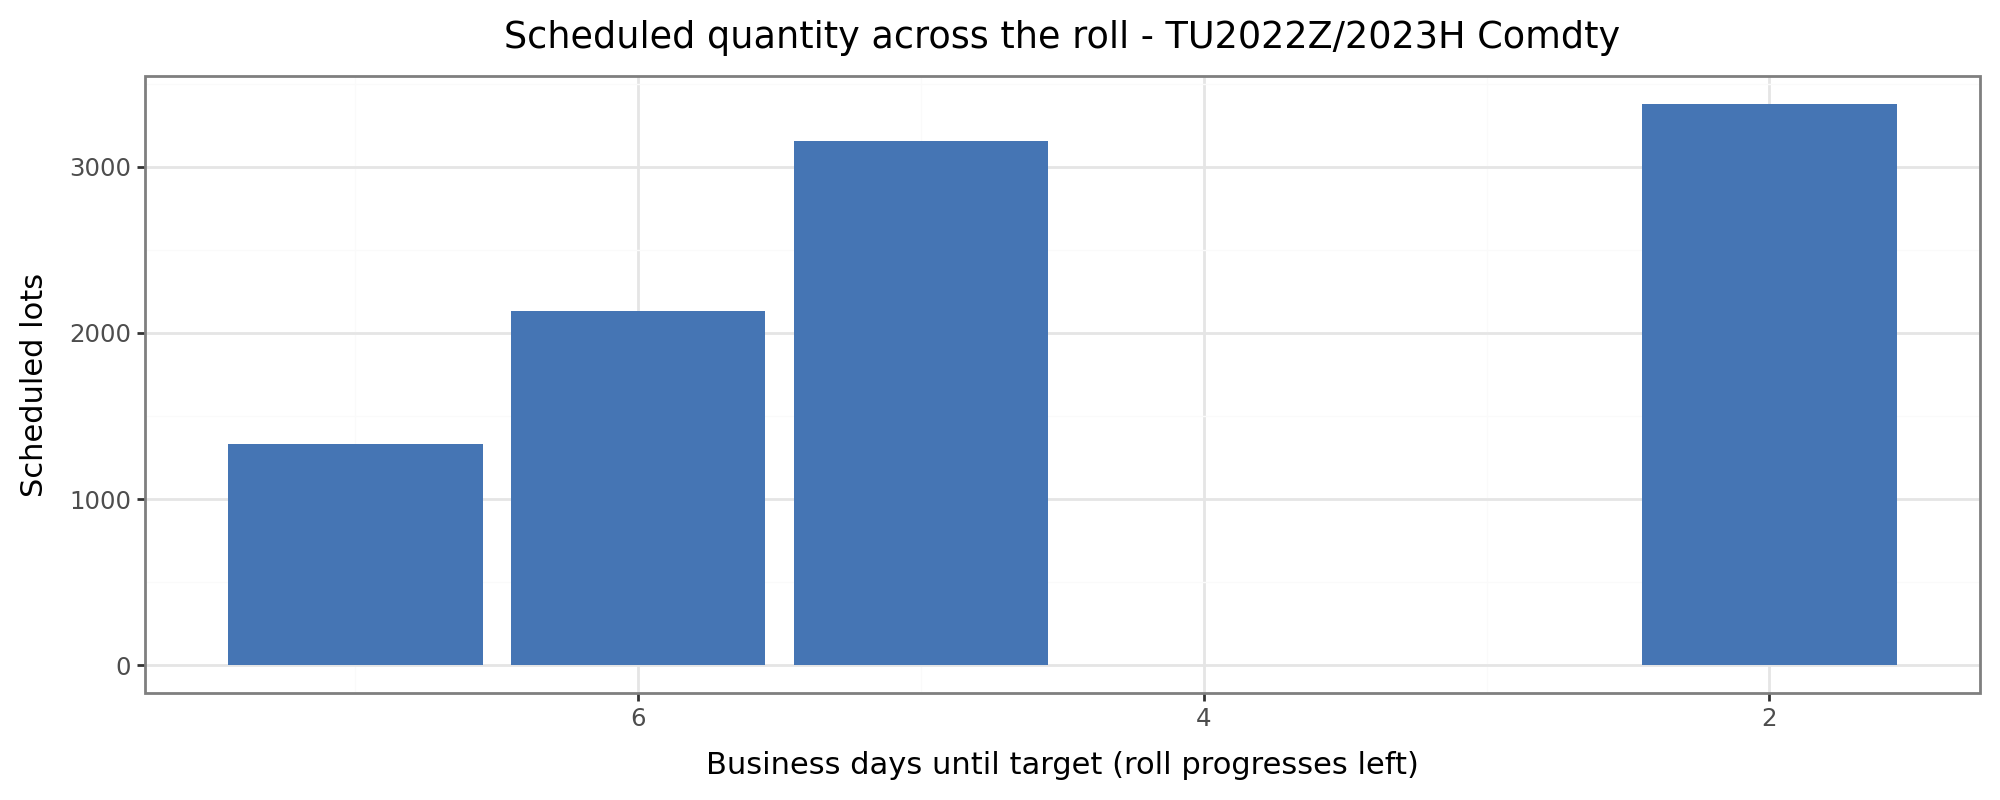

In [136]:
sec = preds['security'].unique()[0]
one = df_cs.filter(pl.col('security') == sec)
sched1 = build_schedules(one, df_cs, target_qty=TARGET_QTY)
by_day1 = (
    sched1.group_by('days_until').agg(scheduled=pl.col('scheduled_qty').sum())
    .sort('days_until', descending=True).to_pandas()
)
print('illustrated roll:', sec)
(
    ggplot(by_day1, aes('days_until', 'scheduled'))
    + geom_col(fill='#4575b4') + scale_x_reverse()
    + labs(title=f'Scheduled quantity across the roll - {sec}',
           x='Business days until target (roll progresses left)', y='Scheduled lots')
    + theme_bw(base_size=11) + theme(figure_size=(10, 4))
)

### A single session, bin by bin

Zoom all the way in to one **session** — a single `security`-`date` the model trades — chosen at
**random on every run** of the cell. One overlaid chart ties the trading day together:

- **Top-of-book** (left axis): the bid and ask through the session (the spread is shaded).
- **Realised execution** (right axis): for each 5-minute bin, the lots our orders *actually* trade,
  attributed to the bin where the fill/cross happens (not the owning schedule bin). Each bin shows a
  pair of stacked bars — **baseline** (left) vs **overlay** (right, hatched) — split into *passive*
  fills (green, spread saved) and *aggressive* crosses (red). Because the overlay reschedules
  execution — resting 2 ticks deeper on a favourable call, crossing immediately on an adverse one —
  its realised volume profile genuinely differs from the baseline's, even though both work the same
  owner-attributed schedule.
- **Signal**: the model's non-zero calls only, drawn at the **mid** and pointing in the predicted
  direction — **▼ −2 down** (favourable for a buyer) and **▲ +2 up** (adverse). Flat (0) bins are omitted.

session: TU2025U/2025Z Comdty  2025-08-26  (98 bins)


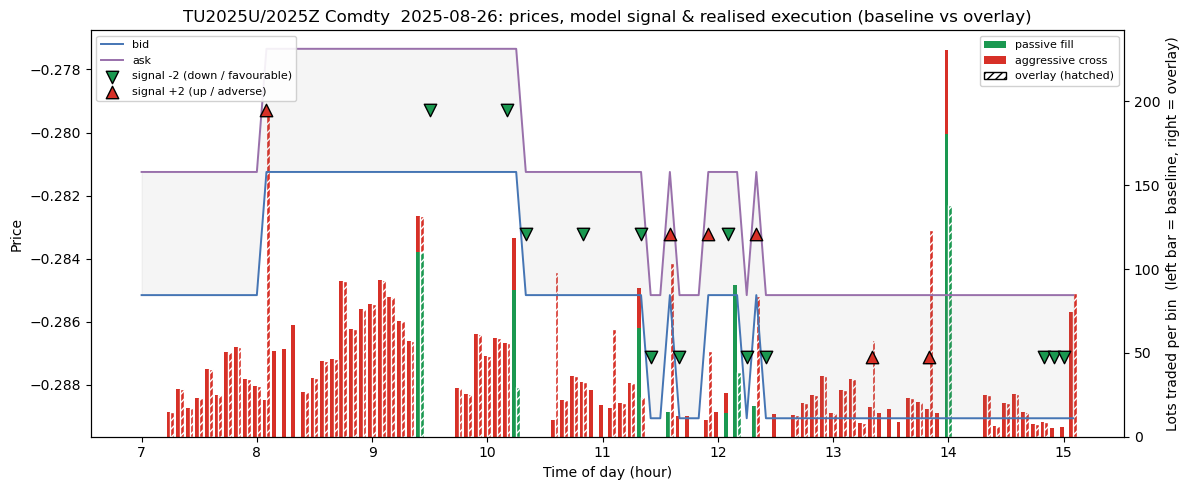


=== TU2025U/2025Z Comdty  2025-08-26: overlay vs baseline (ticks per lot, + = overlay saved) ===
  lots executed (both)  : 3059
  passive fill rate     : baseline 0.190    overlay 0.104
  exec avg price        : baseline -0.2811   overlay -0.2808
  cost vs market VWAP   : baseline +0.768    overlay +0.907    ticks/lot
  cost vs mid           : baseline +0.728    overlay +0.867    ticks/lot
  --> ticks per lot saved by overlay: -0.139   (overlay cost more)


In [137]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from src.vwap import per_security_metrics

# A fresh random session each run: pick a roll the model trades, build its schedule, then take one
# date with a real schedule and at least one directional call, and simulate both strategies on it.
rng = np.random.default_rng()
sec_pool = preds.select('security').unique()['security'].to_list()

sess = sec_sel = date_sel = None
for _ in range(40):
    sec_try = sec_pool[int(rng.integers(len(sec_pool)))]
    sched_sec = (
        df_cs.filter(pl.col('security') == sec_try)
        .pipe(attach_tick_sizes, df_signals)                          # adds `tick`
        .join(preds.select('security', 'date', 'bin_start_time', 'pred'),
              on=['security', 'date', 'bin_start_time'], how='left')
        .pipe(build_schedules, df_cs, target_qty=TARGET_QTY)          # adds `scheduled_qty`
    )
    cand = (
        sched_sec.group_by('date').agg(
            lots=pl.col('scheduled_qty').sum(), n_bins=pl.len(),
            n_signal=(pl.col('pred').fill_null(0) != 0).sum())
        .filter((pl.col('lots') > 0) & (pl.col('n_bins') >= 8) & (pl.col('n_signal') >= 1))
    )
    if cand.height:
        date_sel = cand.row(int(rng.integers(cand.height)), named=True)['date']
        sec_sel, sess = sec_try, sched_sec.filter(pl.col('date') == date_sel)
        break
assert sess is not None, 'no eligible session found - relax the candidate filter'
print(f'session: {sec_sel}  {date_sel}  ({sess.height} bins)')

# Simulate the session under both strategies. Use EXECUTION-time traded volume (passive_traded /
# agg_traded) so the bars reflect WHEN our orders actually trade, not the owning schedule bin --
# this is what makes the baseline and overlay volume profiles differ.
base = simulate_windowed(sess, direction=DIRECTION, fill_model=FILL_MODEL, window=WINDOW)
ovl  = simulate_windowed(sess, direction=DIRECTION, fill_model=FILL_MODEL, window=WINDOW, pred_col='pred')

def _prep(sim):
    return sim.select(
        hour=(pl.col('bin_start_time').dt.hour() + pl.col('bin_start_time').dt.minute() / 60),
        bid='bid_start', ask='ask_start', mid=(pl.col('bid_start') + pl.col('ask_start')) / 2,
        pred=pl.col('pred').fill_null(0),
        passive='passive_traded', aggressive='agg_traded',
    ).to_pandas()
b, o = _prep(base), _prep(ovl)
h = b['hour'].to_numpy()
bw = (np.median(np.diff(np.sort(h))) if len(h) > 1 else 0.08) * 0.40   # paired-bar half-spacing

# ---- one overlaid figure: prices (left axis) + realised volume (right axis) + signal markers ----
fig, axp = plt.subplots(figsize=(12, 5))
axv = axp.twinx()

# Right axis: realised traded volume. Left bar of each pair = baseline, right bar = overlay (hatched);
# each bar stacks passive (green) under aggressive (red).
axv.bar(h - bw / 2, b['passive'],    width=bw, color='#1a9850')
axv.bar(h - bw / 2, b['aggressive'], width=bw, bottom=b['passive'], color='#d73027')
axv.bar(h + bw / 2, o['passive'],    width=bw, color='#1a9850', hatch='////', edgecolor='white')
axv.bar(h + bw / 2, o['aggressive'], width=bw, bottom=o['passive'], color='#d73027', hatch='////', edgecolor='white')
axv.set_ylabel('Lots traded per bin  (left bar = baseline, right = overlay)')
axv.set_ylim(0, None)

# Left axis: top-of-book spread + non-zero signal markers, drawn over the bars. Markers sit at the
# mid and point in the predicted direction: -2 down (favourable) -> downward, +2 up (adverse) -> upward.
axp.plot(h, b['bid'], color='#4575b4', lw=1.4, label='bid')
axp.plot(h, b['ask'], color='#9970ab', lw=1.4, label='ask')
axp.fill_between(h, b['bid'], b['ask'], color='grey', alpha=0.08)
fav, adv = b[b['pred'] == -2], b[b['pred'] == 2]
axp.scatter(fav['hour'], fav['mid'], marker='v', s=80, color='#1a9850', edgecolor='black',
            zorder=6, label='signal -2 (down / favourable)')
axp.scatter(adv['hour'], adv['mid'], marker='^', s=80, color='#d73027', edgecolor='black',
            zorder=6, label='signal +2 (up / adverse)')
axp.set_xlabel('Time of day (hour)'); axp.set_ylabel('Price')
axp.set_zorder(axv.get_zorder() + 1); axp.patch.set_visible(False)    # price/markers above the bars

axp.legend(loc='upper left', fontsize=8, framealpha=0.9)
axv.legend(handles=[Patch(facecolor='#1a9850', label='passive fill'),
                    Patch(facecolor='#d73027', label='aggressive cross'),
                    Patch(facecolor='white', edgecolor='black', hatch='////', label='overlay (hatched)')],
           loc='upper right', fontsize=8, framealpha=0.9)
axp.set_title(f'{sec_sel}  {date_sel}: prices, model signal & realised execution (baseline vs overlay)')
fig.tight_layout(); plt.show()

# ---- within-session summary: ticks per lot the overlay saved vs the baseline ----
# Reuse the project's cost framework (one row per security; this session is a single security-date).
mb = per_security_metrics(base, DIRECTION).row(0, named=True)   # baseline, this session
mo = per_security_metrics(ovl,  DIRECTION).row(0, named=True)   # overlay,  this session
# Both strategies execute the same lots against the same prices, so the benchmark cancels: the
# saving is purely the execution-price difference in ticks (cost-vs-VWAP and cost-vs-mid agree).
saved = mb['cost_vs_vwap_ticks'] - mo['cost_vs_vwap_ticks']
verdict = 'overlay saved' if saved > 0 else ('overlay cost more' if saved < 0 else 'tie')
print(f'\n=== {sec_sel}  {date_sel}: overlay vs baseline (ticks per lot, + = overlay saved) ===')
print(f'  lots executed (both)  : {mb["total_qty"]:.0f}')
print(f'  passive fill rate     : baseline {mb["passive_rate"]:.3f}    overlay {mo["passive_rate"]:.3f}')
print(f'  exec avg price        : baseline {mb["exec_avg_price"]:.4f}   overlay {mo["exec_avg_price"]:.4f}')
print(f'  cost vs market VWAP   : baseline {mb["cost_vs_vwap_ticks"]:+.3f}    overlay {mo["cost_vs_vwap_ticks"]:+.3f}    ticks/lot')
print(f'  cost vs mid           : baseline {mb["cost_vs_mid_ticks"]:+.3f}    overlay {mo["cost_vs_mid_ticks"]:+.3f}    ticks/lot')
print(f'  --> ticks per lot saved by overlay: {saved:+.3f}   ({verdict})')

## Summary & caveats

- The **walk-forward** design keeps every number out-of-sample: time-of-roll signal scaling, the
  ordered-logit train/val/test split, and the volume curves all use only information available before
  the bin being executed.
- The **baseline VWAP** quantifies the spread it captures passively; the **overlay** reshapes execution
  around the model's directional call.
- The **survival window** is the main lever on passive-fill rate: in tick-constrained books one bin of
  flow rarely clears the queue, so orders must rest across several bins to fill. The sweep shows the
  fill-rate vs adverse-selection trade-off; pick the window where cost vs VWAP bottoms out.
- Whether the overlay beats the baseline is governed by the model's precision/recall on the +/-2 tails and
  by the fill probability of the 2-tick-deeper passive order. With modest precision (~0.3) the favourable
  signal misfires often, so the gains from resting deeper trade off against the cost of crossing when the
  limit misses - exactly the cost trade-off the strategy is designed around. The per-qcode chart shows
  where the edge is real.
- The hi-lo fill model assumes a resting limit fills in full once the bin's range reaches it; the queue
  model is a more conservative alternative. Real fill behaviour at the deeper level is uncertain with only
  top-of-book depth.